**Tugas : Klasifikasi dengan Decision Tree dan Random Forest**

Nama:

Muhammad Abdillah Mutashim (24523239)

ibrahim ivanka(24523279 )

Muhamad Aldio Khairullah Santoso(24523250)

Dataset:

Nama: Iris Dataset (Classification)

Sumber: sklearn.datasets

Kriteria: Memiliki 4 fitur (sepal length, sepal width, petal length, petal width) dan 1 label (spesies).

**1. Import Library dan Load Dataset**

Penjelasan: Pertama, kita mengimpor library yang dibutuhkan untuk pemrosesan data, pemodelan mesin pembelajaran, dan evaluasi hasil klasifikasi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("Informasi Dataset:")
print(X.info())
print("\nTarget Class:", iris.target_names)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Target Class: ['setosa' 'versicolor' 'virginica']


**2.Preprocessing: Pembagian Data**

Penjelasan: Kita membagi dataset menjadi dua bagian: Data Latih (Training) untuk melatih model dan Data Uji (Testing) untuk mengevaluasi seberapa akurat model memprediksi data baru yang belum pernah dilihat sebelumnya.

In [2]:
# Bagi data menjadi 80% latih dan 20% uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data latih: 120
Jumlah data uji: 30


**3.Model 1: Decision Tree**

Penjelasan: Membangun model Decision Tree sederhana. Algoritma ini bekerja dengan cara membagi data berdasarkan aturan keputusan yang menyerupai struktur poho

In [3]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Akurasi Decision Tree:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Akurasi Decision Tree: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**4.Visualisasi Pohon Keputusan (Decision Tree)**

Penjelasan: Visualisasi ini membantu kita memahami bagaimana model mengambil keputusan berdasarkan fitur yang ada.

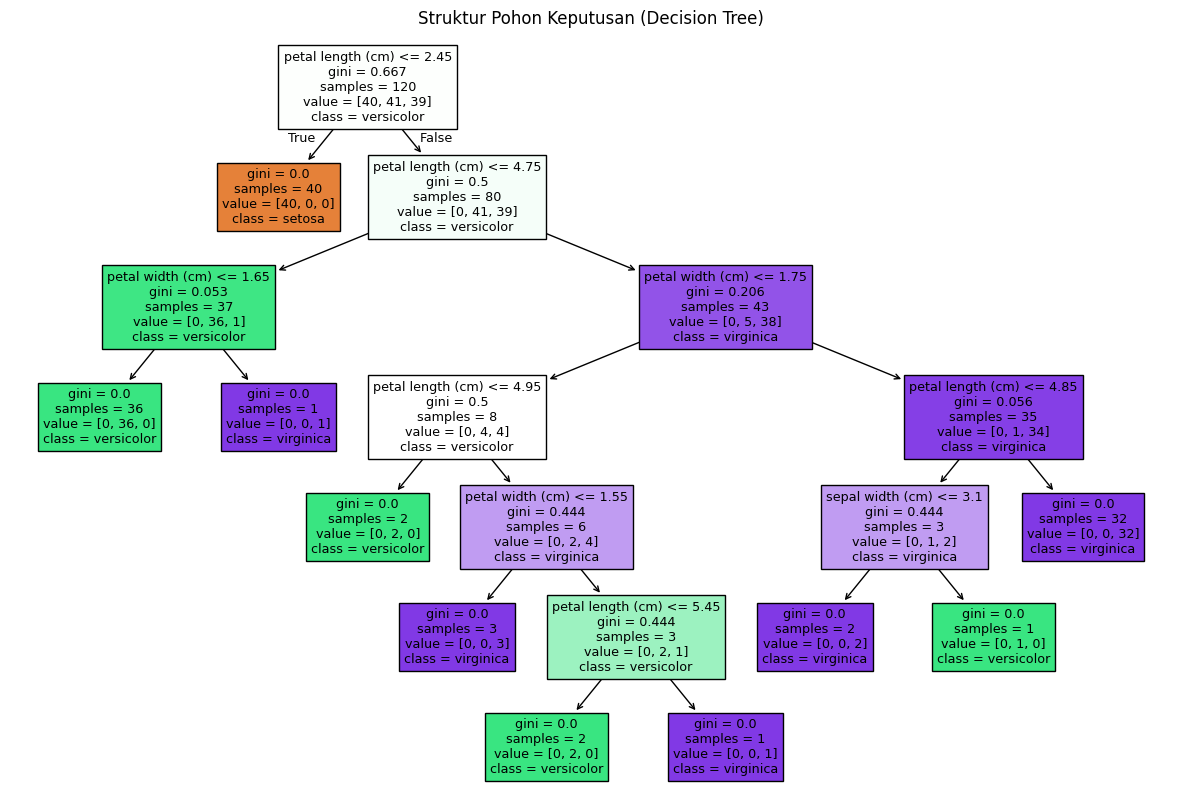

In [4]:
plt.figure(figsize=(15,10))
plot_tree(dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Struktur Pohon Keputusan (Decision Tree)")
plt.show()

**5.Model 2: Random Forest**

Penjelasan: Membangun model Random Forest. Parameter n_estimators menentukan berapa banyak pohon keputusan yang akan dibuat dalam "hutan" tersebut.

In [5]:
# Menggunakan 100 pohon keputusan (n_estimators=100)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Akurasi Random Forest:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Akurasi Random Forest: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



6.Analisis Perbandingan & Jawaban Pertanyaan
Penjelasan: Bagian ini berisi evaluasi mendalam berdasarkan hasil eksekusi model di atas.

Analisis:

1.Performa Terbaik: Umumnya Random Forest memberikan akurasi yang lebih stabil karena merupakan kumpulan dari banyak pohon (ensemble).

2.Kelebihan/Kekurangan: Decision Tree mudah dipahami (visual) tetapi rentan terhadap data yang sedikit berubah. Random Forest lebih akurat tetapi lebih sulit diinterpretasikan (black box).

3.Indikasi Overfitting: Jika akurasi pada data latih 100% sedangkan data uji jauh di bawahnya, maka Decision Tree mengalami overfitting (belajar terlalu detail hingga ke noise data).

4.Pengaruh Fitur: Fitur seperti petal length dan petal width biasanya menjadi fitur paling berpengaruh dalam memisahkan jenis bunga Iris.

Jawaban Pertanyaan:

1.Perbedaan Mendasar: Decision Tree adalah pohon tunggal, sedangkan Random Forest adalah kumpulan (ensemble) dari banyak Decision Tree yang hasilnya digabungkan (voting).

2.Overfitting: Decision Tree rentan karena terus membelah cabang sampai data latih terklasifikasi sempurna. Random Forest mengatasinya dengan teknik bagging dan pemilihan fitur acak sehingga varians berkurang.

3.Bagging: Fungsinya adalah mengambil sampel data secara acak dengan pengembalian untuk melatih setiap pohon yang berbeda, sehingga model lebih tangguh.

4.Kapan Decision Tree Cocok: Digunakan saat kita memerlukan model yang sangat mudah dijelaskan kepada orang awam atau ketika dataset sangat sederhana.